# SMC tidal expansion and predictions for Spec-S5

The SMC-LMC collision results in the SMC being tidally disrupted. This tidal disruption is observed with Gaia (e.g. Zivick+2021 ApJ 910 36). The tidal radius has been shown to be sensitive to the dark matter profile and hence the underlying dark matter physics. So, if Spec-S5 can help us precisely determine the SMC's tidal radius, we can use the SMC's tidal disruption as a probe of dark matter physics.

Here, we will use a simulation of the LMC-SMC collision (from Model 2 of Besla+2012 MNRAS 421 3 2109) to understand the observables to go after with Spec-S5. We will use a snapshot that is 100 Myr after the collision as this epoch is close to the present day.

In [1]:
import numpy as np
import transform_galaxy as tg
import disk_utils as du
import matplotlib.pyplot as plt
import plots_init as pi
import snap_analysis as sna
import smc_copilot as sc

## Extracting Model 2 snapshots

Extracting the simulation snapshot.

In [2]:
snaps = sna.get_snaps('/xdisk/gbesla/himansh/besla12/lmc_smc_mw/snaps/', init_string='snapshot_', ext = '')
pd_snap = snaps[69]

## Extracting COMs

Extracting the COM position and velocity of the SMC in the simulation snapshot.

In [3]:
com_pos = np.load('/xdisk/gbesla/himansh/smc_b12/accessory/old_stars/smc_kine_center_array_model2.npy')
com_vel = np.load('/xdisk/gbesla/himansh/besla12/lmc_smc_mw/com_orbit/stars_com/SMC_com_vel.npy')

pd_com_pos = com_pos[:, 69]
pd_com_vel = com_vel[:, 69]

## Extracting inclinations

Extracting the inclination of the SMC in the simulation snapshot. Note that since the SMC is tidally disrupting, it is very difficult to estimate the inclination, both in simulations and in observations. By assuming inclinations that span a 90$^\circ$ range, we will show that the velocity field diagnostics that trace the SMC's tidal disruption are not sensitive to the assumed inclination. 

In [4]:
theta = np.load('/xdisk/gbesla/himansh/smc_b12/accessory/old_stars/smc_theta_array_model2.npy')
phi = np.load('/xdisk/gbesla/himansh/smc_b12/accessory/old_stars/smc_phi_array_model2.npy')

pd_theta = theta[69]
pd_theta_l = pd_theta - (np.pi/4)
pd_theta_u = pd_theta + (np.pi/4)
pd_phi = phi[69]

## Extracting positions

Extract the positions of the SMC's star particles.

In [5]:
pd_pos, pd_vel, pd_mass = sc.extract_smc(pd_snap)

## Translating to COM

Translating the positions of star particles to the SMC's center.

In [6]:
pd_pos_1 = tg.transGal.translate_gal(pd_pos, pd_com_pos)
pd_vel_1 = tg.transGal.translate_gal(pd_vel, pd_com_vel)

## Aligning the SMC

Aligning the SMC to the assumed inclination.

In [7]:
pd_pos_2 = tg.rotGal.rotate_gal(pd_pos_1, [-pd_phi, -pd_theta, 0])
pd_vel_2 = tg.rotGal.rotate_gal(pd_vel_1, [-pd_phi, -pd_theta, 0])

pd_pos_2_l = tg.rotGal.rotate_gal(pd_pos_1, [-pd_phi, -pd_theta_l, 0])
pd_vel_2_l = tg.rotGal.rotate_gal(pd_vel_1, [-pd_phi, -pd_theta_l, 0])

pd_pos_2_u = tg.rotGal.rotate_gal(pd_pos_1, [-pd_phi, -pd_theta_u, 0])
pd_vel_2_u = tg.rotGal.rotate_gal(pd_vel_1, [-pd_phi, -pd_theta_u, 0])

## LOS cut

Lets consider only those particles which are upto +-2 kpc above and below the disk plane. With precise distances such a selection can be made in observations as well.

In [8]:
#Lets apply a LOS cut of +- 2kpc
idxs_pd = np.abs(pd_pos_2[2, :]) < 2
idxs_pd_l = np.abs(pd_pos_2_l[2, :]) < 2
idxs_pd_u = np.abs(pd_pos_2_u[2, :]) < 2

pd_pos_3 = pd_pos_2[:, idxs_pd]
pd_vel_3 = pd_vel_2[:, idxs_pd]

pd_pos_3_l = pd_pos_2_l[:, idxs_pd_l]
pd_vel_3_l = pd_vel_2_l[:, idxs_pd_l]

pd_pos_3_u = pd_pos_2_u[:, idxs_pd_u]
pd_vel_3_u = pd_vel_2_u[:, idxs_pd_u]

## Obtaining velocity profiles

Obtain the SMC's radial velocity profile for the 3 assumed inclination.

In [9]:
rgrid, vrad_pd = du.get_disk_vrad_profile(pd_pos_3, pd_vel_3, r_min = 0, r_max = 5, n_bins = 25)
rgrid, vrad_pd_l = du.get_disk_vrad_profile(pd_pos_3_l, pd_vel_3_l, r_min = 0, r_max = 5, n_bins = 25)
rgrid, vrad_pd_u = du.get_disk_vrad_profile(pd_pos_3_u, pd_vel_3_u, r_min = 0, r_max = 5, n_bins = 25)

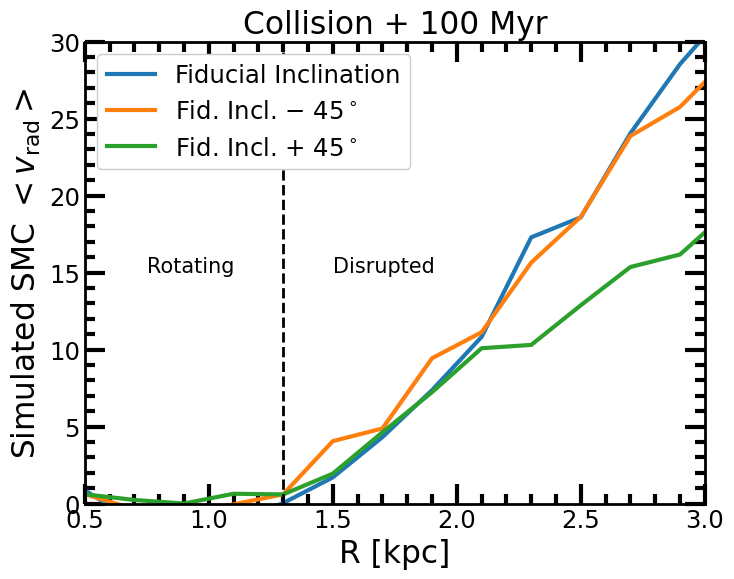

In [27]:
fig = plt.figure(figsize = (8, 6))
ax0 = fig.add_subplot(1, 1, 1)
ax0.plot(rgrid, vrad_pd, linewidth = 3, label = 'Fiducial Inclination')
ax0.plot(rgrid, vrad_pd_l, linewidth = 3, label = r'Fid. Incl. $-$ 45$^\circ$')
ax0.plot(rgrid, vrad_pd_u, linewidth = 3, label = r'Fid. Incl. $+$ 45$^\circ$')
ax0.annotate("Rotating", (0.75, 15), fontsize = 15)
ax0.annotate("Disrupted", (1.5, 15), fontsize = 15)
ax0.vlines(1.3, 0, 30, linestyle = '--', color = 'k',  linewidth = 2)
ax0.set_xlim(0.5, 3)
ax0.set_ylim(0, 30)
ax0.set_xlabel('R [kpc]')
ax0.set_ylabel(r'Simulated SMC $<v_{\rm rad}>$')
ax0.set_title('Collision + 100 Myr')
ax0.legend(fancybox = True, framealpha = 1, loc = 'upper left')
pi.aesthetic(ax0)
plt.savefig("vrad_prediction_specS5.jpg", bbox_inches = "tight", dpi = 300)
plt.show()

The azimuthally averaged radial velocities diverge at 1.3 kpc. This radius is the SMC's tidal radius. Note that it is not significantly dependent on the SMC's inclination. Hence, with just the LOS velocities that Spec-S5 will give us, we will be able to reliably determine the SMC's tidal radius. Spec-S5 will be able to get us the line of sight velocities of a star of G = 20 mag (a red clump star at the SMC distance) with an accuracy better than 1 km/s. We will get even better accuracy if we average a few thousand stars in each radial bin.

If we are able to determine the SMC's tidal radius with precision, then we can relate this tidal radius to the slope of the SMC's dark matter profile (e.g. Du+2024 PRD 110 023019) as well as the interaction cross section if SIDM is assumed (e.g. Zhang+2024 ApJL 968 L13).